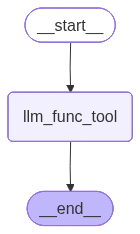

In [2]:
def add(a:int,b:int)->int:
    """ Docstring for add
    
    :param a: Description
    :type a: int
    :param b: Description
    :type b: int
    :return: Description
    :rtype: int"""

    return a+b


from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage,AIMessage,AnyMessage
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

llm = ChatOpenAI(model="gpt-4o-mini")

llm_tool = llm.bind_tools([add])

class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]


def llm_func_tool(state:State):
    return {"messages":llm_tool.invoke(state['messages'])}

initial_message = [AIMessage(content="Hi How can I help?",name="llmmodel")]
initial_message.append(HumanMessage(content="I want to learn programming",name="Harika"))

aimessage = AIMessage(content="Which PL do you want to learn",name="llmmodel")

add_messages(initial_message,aimessage)

builder = StateGraph(State)

builder.add_node('llm_func_tool',llm_func_tool)
builder.add_edge(START,'llm_func_tool')
builder.add_edge('llm_func_tool',END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
messages = graph.invoke({"messages":"What is 2+2"})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

What is 2+2
================================== Ai Message ==================================
Tool Calls:
  add (call_1oiBxAjUAFwuLK0uATJPYMTo)
 Call ID: call_1oiBxAjUAFwuLK0uATJPYMTo
  Args:
    a: 2
    b: 2
